## 1) Imports & constants

In [ ]:
from __future__ import annotations
import json

import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# ---- Paths ----
CWD = Path().resolve()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
SRC_DIR = PROJECT_ROOT / "src"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ---- Reproducibility ----
RANDOM_STATE = 50
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

## 2) Config

Centralized settings

In [ ]:
@dataclass
class ExperimentConfig:
    k_values: list[int]
    label_column: str
    positive_label: str
    numeric_qi: list[str]
    categorical_qi: list[str]
    local_csv_path: str = ""  # set to a local Adult CSV if OpenML is not available

    def validate(self) -> None:
        if not self.k_values or any(int(k) < 2 for k in self.k_values):
            raise ValueError("k_values must contain integers >= 2")
        if not self.label_column:
            raise ValueError("label_column is required")
        if not self.positive_label:
            raise ValueError("positive_label is required")
        if not self.numeric_qi and not self.categorical_qi:
            raise ValueError("Need at least one QI column")
        if set(self.numeric_qi) & set(self.categorical_qi):
            raise ValueError("numeric_qi and categorical_qi must be disjoint")

    @property
    def qi_columns(self) -> list[str]:
        return list(self.numeric_qi) + list(self.categorical_qi)

    @staticmethod
    def from_dict(d: Dict[str, Any]) -> "ExperimentConfig":
        cfg = ExperimentConfig(**d)
        cfg.validate()
        return cfg


cfg = ExperimentConfig(
    k_values=[2, 5, 10, 20, 50],
    label_column="income",
    positive_label=">50K",
    numeric_qi=["age", "hours-per-week"],
    categorical_qi=[
        "workclass",
        "education",
        "marital-status",
        "occupation",
        "race",
        "sex",
        "native-country",
    ],
    local_csv_path="",  # e.g. str(PROJECT_ROOT / "adult.csv")
)
cfg.validate()

print(json.dumps(asdict(cfg), indent=2, ensure_ascii=False))

{
  "k_values": [
    2,
    5,
    10,
    20,
    50
  ],
  "label_column": "income",
  "positive_label": ">50K",
  "numeric_qi": [
    "age",
    "hours-per-week"
  ],
  "categorical_qi": [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "race",
    "sex",
    "native-country"
  ],
  "local_csv_path": ""
}


## 3) Data I/O 


- `read_input()`: try OpenML first; if it fails, load from `cfg.local_csv_path`

- `write_output_df()`: save results into `outputs/` (CSV)


In [ ]:
from sklearn.datasets import fetch_openml

def read_input(config: ExperimentConfig) -> pd.DataFrame:
    """Return the Adult dataframe with a normalized label column `income`."""
    # 1) Try OpenML first
    try:
        bunch = fetch_openml("adult", version=2, as_frame=True)
        X = bunch.data.copy()
        y = bunch.target.copy()
        df = X

        # OpenML uses 'class' as the label
        df["income"] = y
        return df
    except Exception as e:
        print(f"OpenML load failed ({e.__class__.__name__}): {e}")

    # 2) Local CSV fallback
    if not config.local_csv_path:
        raise RuntimeError(
            "OpenML is unavailable and cfg.local_csv_path is empty. "
            "Set cfg.local_csv_path to a local Adult CSV."
        )

    path = Path(config.local_csv_path)
    if not path.exists():
        raise FileNotFoundError(f"local_csv_path not found: {path}")

    df = pd.read_csv(path)

    # Normalize label column to 'income'
    if "income" not in df.columns and "class" in df.columns:
        df = df.rename(columns={"class": "income"})
    return df

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

def write_output_df(df: pd.DataFrame, filename: str) -> Path:
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path

df_raw = normalize_columns(read_input(cfg))
df_raw.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## 4) k-anonymity

- `clean_adult()`: handle missing values and keep only needed columns
- `run_k_anonymity()`: run Mondrian for a given k and return anonymized data

In [ ]:
import importlib

import k_anonymity.mondrian as mondrian_mod

# Reload to pick up local code changes without restarting the kernel
importlib.reload(mondrian_mod)

assert_k_anonymous = mondrian_mod.assert_k_anonymous
encode_raw_as_generalized = mondrian_mod.encode_raw_as_generalized
mondrian_anonymize = mondrian_mod.mondrian_anonymize

def clean_adult(df: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    """Minimal cleaning: replace '?' -> NaN and drop rows missing in QI/label."""
    df = df.copy()

    # Standardize string columns
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].astype(str).str.strip()

    # Replace '?' with NaN
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].replace({"?": np.nan})

    needed = list(config.qi_columns) + [config.label_column]
    missing_cols = [c for c in needed if c not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    df = df[needed].dropna().reset_index(drop=True)

    # Coerce numeric
    for c in config.numeric_qi:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna().reset_index(drop=True)
    return df

def run_k_anonymity(df_clean: pd.DataFrame, *, k: int, config: ExperimentConfig) -> pd.DataFrame:
    """Run Mondrian k-anonymity and return the anonymized dataframe."""
    res = mondrian_anonymize(
        df_clean,
        k=k,
        qi_columns=config.qi_columns,
        categorical_qi=config.categorical_qi,
        numeric_qi=config.numeric_qi,
        label_column=config.label_column,
    )
    assert_k_anonymous(res.df_anonymized, k=k)
    return res.df_anonymized

df_clean = clean_adult(df_raw, cfg)
df_clean.head()

,age,hours-per-week,workclass,education,marital-status,occupation,race,sex,native-country,income
0,25,40,Private,11th,Never-married,Machine-op-inspct,Black,Male,United-States,<=50K
1,38,50,Private,HS-grad,Married-civ-spouse,Farming-fishing,White,Male,United-States,<=50K
2,28,40,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,White,Male,United-States,>50K
3,44,40,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Black,Male,United-States,>50K
4,34,30,Private,10th,Never-married,Other-service,White,Male,United-States,<=50K


## 5) Run k-anonymity

Generate:
- `raw_gen`: raw dataset encoded into generalized schema
- `anon[k]`: k-anonymized dataset for each k

In [ ]:
SAMPLE_N = None  # set None to use the full dataset

# Build a base dataframe first, then run k-anonymity.
df_base = df_clean.iloc[:SAMPLE_N].reset_index(drop=True) if SAMPLE_N is not None else df_clean

raw_gen = encode_raw_as_generalized(
    df_base,
    qi_columns=cfg.qi_columns,
    categorical_qi=cfg.categorical_qi,
    numeric_qi=cfg.numeric_qi,
    label_column=cfg.label_column,
 )

anon = {k: run_k_anonymity(df_base, k=k, config=cfg) for k in cfg.k_values}

{
    "rows": len(df_base),
    "k_values": list(cfg.k_values),
    "raw_gen_cols": len(raw_gen.columns),
}

{'rows': 45222, 'k_values': [2, 5, 10, 20, 50], 'raw_gen_cols': 14}

## 6) Save outputs + Linear SVM evaluation

- Save the raw generalized and each k-anonymized dataset to `outputs/`
- Train Linear SVM
- Produce tables and plots

In [ ]:
import importlib

import k_anonymity.ml_eval as ml_eval_mod

# Reload to pick up local code changes without restarting the kernel
importlib.reload(ml_eval_mod)

EvalConfig = ml_eval_mod.EvalConfig
build_feature_columns = ml_eval_mod.build_feature_columns
evaluate_dataset = ml_eval_mod.evaluate_dataset
make_split_indices = ml_eval_mod.make_split_indices

# ---- Save datasets ----
raw_path = write_output_df(raw_gen, "adult_raw_generalized.csv")
print("Saved raw generalized:", raw_path)

for k, df_k in anon.items():
    path = write_output_df(df_k, f"adult_k{k}.csv")
    print(f"Saved anonymized k={k}:", path)

# ---- ML evaluation ----
cat_cols, num_cols = build_feature_columns(numeric_qi=cfg.numeric_qi, categorical_qi=cfg.categorical_qi)

eval_cfg = EvalConfig(
    label_column=cfg.label_column,
    positive_label=cfg.positive_label,
    categorical_columns=cat_cols,
    numeric_columns=num_cols,
    test_size=0.25,
    random_state=RANDOM_STATE,
 )

train_idx, test_idx = make_split_indices(raw_gen, cfg=eval_cfg)

def eval_one(name: str, df_set: pd.DataFrame) -> pd.DataFrame:
    res = evaluate_dataset(df_set, cfg=eval_cfg, train_idx=train_idx, test_idx=test_idx)
    rows = []
    for model_name, metrics in res.items():
        rows.append({"dataset": name, "model": model_name, **metrics})
    return pd.DataFrame(rows)

frames = [eval_one("raw", raw_gen)]
for k in cfg.k_values:
    frames.append(eval_one(f"k={k}", anon[k]))

results_df = pd.concat(frames, ignore_index=True)
results_df = results_df.sort_values(["model", "dataset"]).reset_index(drop=True)
results_df

Saved raw generalized: C:\Users\User\OneDrive - 國立臺灣科技大學\桌面\作業\隱私資訊安全\HW1\outputs\adult_raw_generalized.csv
Saved anonymized k=2: C:\Users\User\OneDrive - 國立臺灣科技大學\桌面\作業\隱私資訊安全\HW1\outputs\adult_k2.csv
Saved anonymized k=5: C:\Users\User\OneDrive - 國立臺灣科技大學\桌面\作業\隱私資訊安全\HW1\outputs\adult_k5.csv
Saved anonymized k=10: C:\Users\User\OneDrive - 國立臺灣科技大學\桌面\作業\隱私資訊安全\HW1\outputs\adult_k10.csv
Saved anonymized k=20: C:\Users\User\OneDrive - 國立臺灣科技大學\桌面\作業\隱私資訊安全\HW1\outputs\adult_k20.csv
Saved anonymized k=50: C:\Users\User\OneDrive - 國立臺灣科技大學\桌面\作業\隱私資訊安全\HW1\outputs\adult_k50.csv


,dataset,model,misclassification,accuracy,precision,recall,auc
0,k=10,svm_linear,0.188661,0.811339,0.660740,0.490721,0.850813
1,k=2,svm_linear,0.175394,0.824606,0.690554,0.529622,0.869657
2,k=20,svm_linear,0.193260,0.806740,0.656838,0.461099,0.848934
3,k=5,svm_linear,0.186538,0.813462,0.661388,0.506781,0.851208
4,k=50,svm_linear,0.193614,0.806386,0.652563,0.467880,0.844878
5,raw,svm_linear,0.166637,0.833363,0.713687,0.547109,0.884869


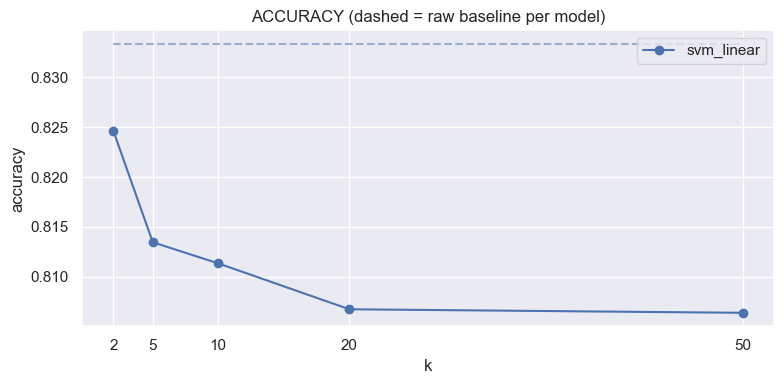

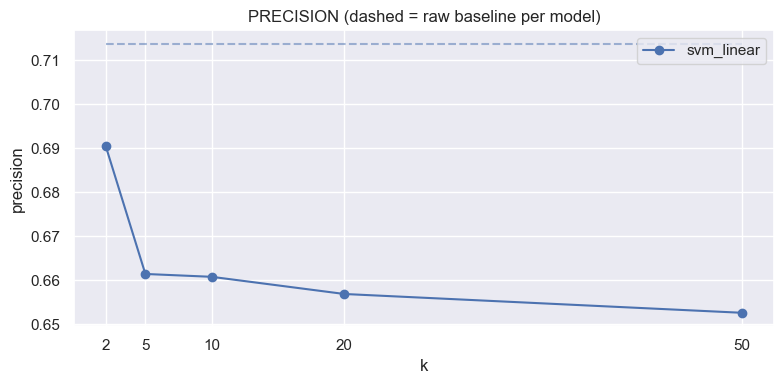

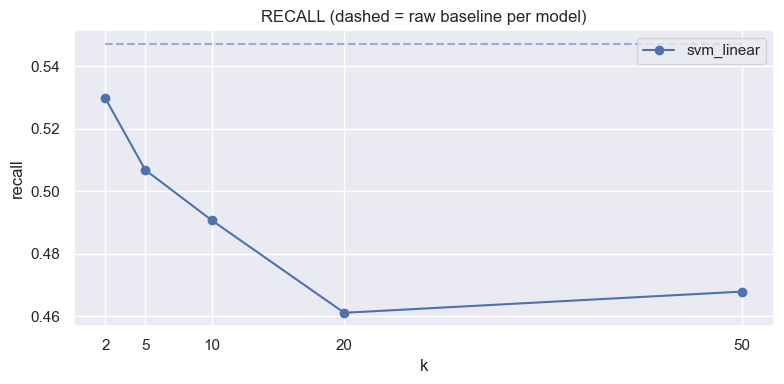

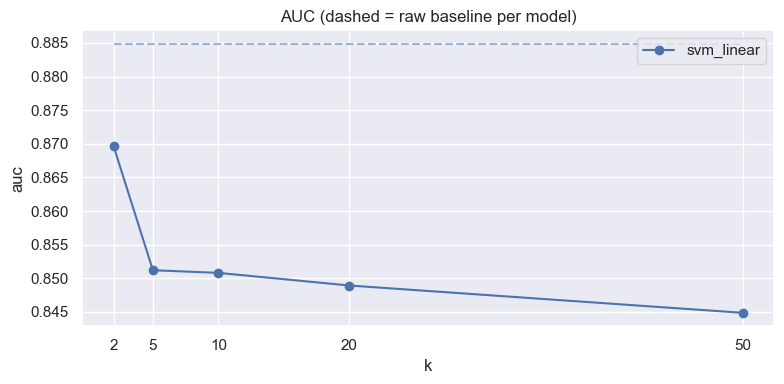

In [ ]:
# ---- Plots: accuracy & AUC vs k ----

def _parse_k(ds: str) -> Optional[int]:
    if ds.startswith("k="):
        return int(ds.split("=")[1])
    return None

plot_df = results_df.copy()
plot_df["k"] = plot_df["dataset"].map(_parse_k)

for metric in ["accuracy","precision","recall","auc"]:
    plt.figure(figsize=(8, 4))
    for model_name, g in plot_df.groupby("model"):
        raw_val = float(g.loc[g["dataset"] == "raw", metric].iloc[0])
        gk = g.dropna(subset=["k"]).sort_values("k")
        plt.plot(gk["k"], gk[metric], marker="o", label=f"{model_name}")
        plt.hlines(raw_val, xmin=min(cfg.k_values), xmax=max(cfg.k_values), linestyles="dashed", alpha=0.5)

    plt.title(f"{metric.upper()} (dashed = raw baseline per model)")
    plt.xlabel("k")
    plt.ylabel(metric)
    plt.xticks(cfg.k_values)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Results

- **data preturbing method:**
  - I apply Mondrian  k-anonymity to quasi-identifiers.
  - raw generalization format:
    - Numeric QIs (age, hours-per-week) → interval strings like [min,max], plus two numeric features per QI: *_mid (interval midpoint) and *_width (interval width).
    - Categorical QIs (e.g., education, occupation) → set strings like {v1|v2|...}.
  - The income column is kept unchanged.

- **Machine learning model:**
  - Model: scikit-learn `LinearSVC(C=1.0)`.

- **Effectiveness:**
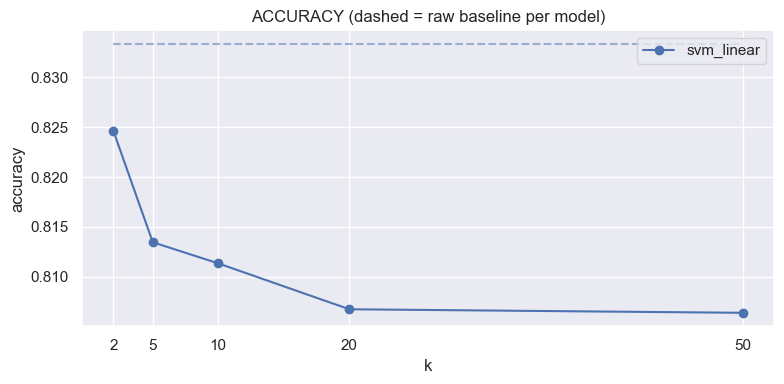
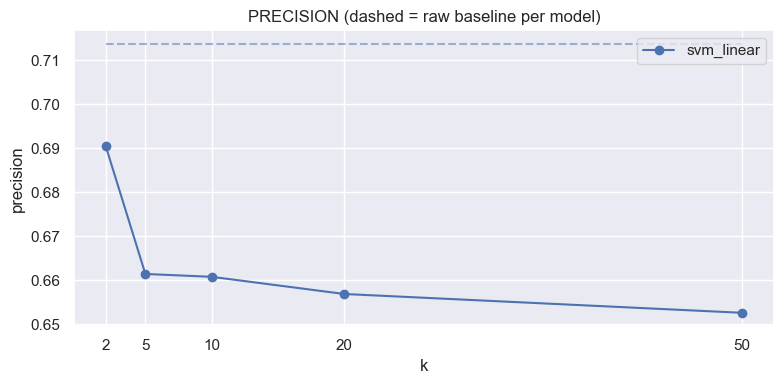
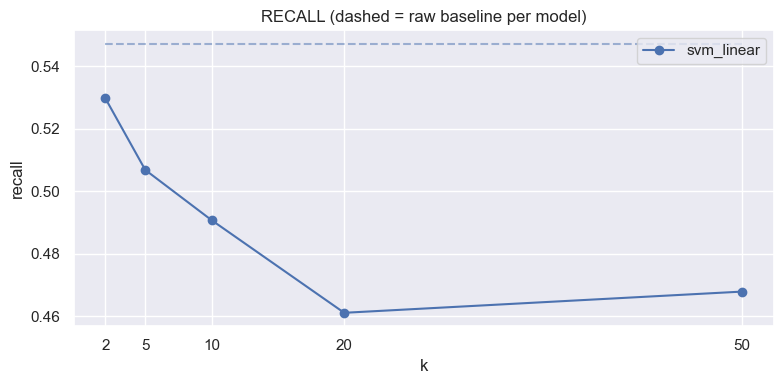
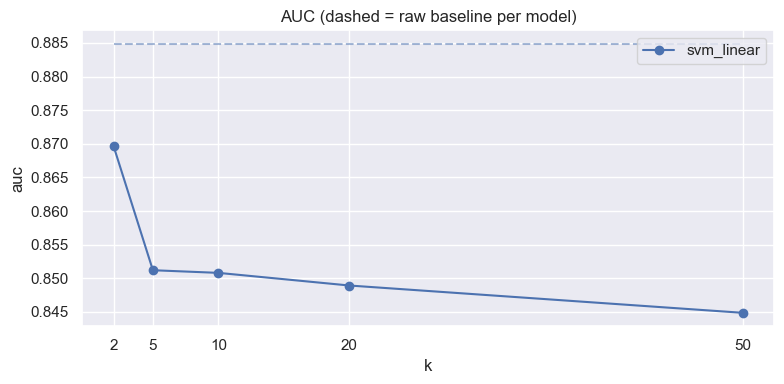

- **Privacy level:**
  - k values evaluated: [2, 5, 10, 20, 50].
